In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset=pd.read_csv('Mall_Customers.csv')

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
x=dataset.iloc[:,[3,4]].values

In [5]:
!pip install seaborn

Text(0, 0.5, 'Number of Clusters')

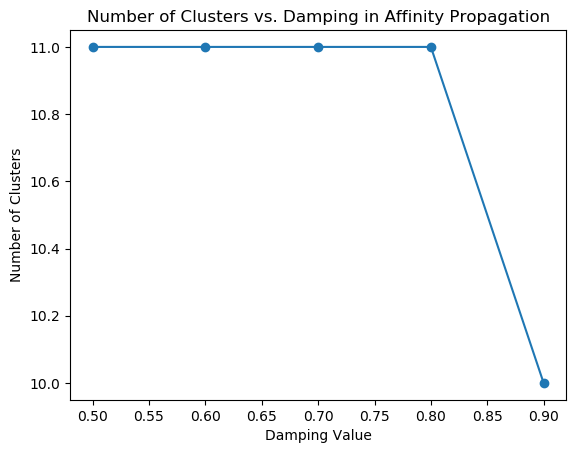

In [11]:
from sklearn.cluster import AffinityPropagation
damping_values=np.linspace(0.5,0.9,5)
list1=[]
for damping in damping_values:
        affinity=AffinityPropagation(damping=damping,max_iter=200)
        affinity.fit(x)
        n_clusters=len(set(affinity.labels_))
        list1.append(n_clusters)
    
plt.plot(damping_values,list1,marker='o')
plt.title('Number of Clusters vs. Damping in Affinity Propagation')
plt.xlabel('Damping Value')
plt.ylabel('Number of Clusters')

In [14]:
from sklearn.cluster import AffinityPropagation
damping=0.5
affinity=AffinityPropagation(damping=damping,max_iter=200)
affinity=affinity.fit(x)

In [15]:
supervised=pd.DataFrame(dataset)                                                              

In [16]:
supervised['Cluster_group']=affinity.labels_

In [17]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,2
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,9
196,197,Female,45,126,28,10
197,198,Male,32,126,74,9
198,199,Male,32,137,18,10


In [18]:
supervised.to_csv("Cluster.csv",index=False)

In [19]:
centroids=affinity.cluster_centers_

In [20]:
centroids

array([[ 25,   5],
       [ 28,  82],
       [ 28,  32],
       [ 46,  51],
       [ 60,  52],
       [ 67,  40],
       [ 77,  12],
       [ 78,  90],
       [ 78,  73],
       [103,  85],
       [103,  23]], dtype=int64)

C:\Users\lenovo\anaconda3\envs\aiml\lib\site-packages\seaborn\regression.py:582: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


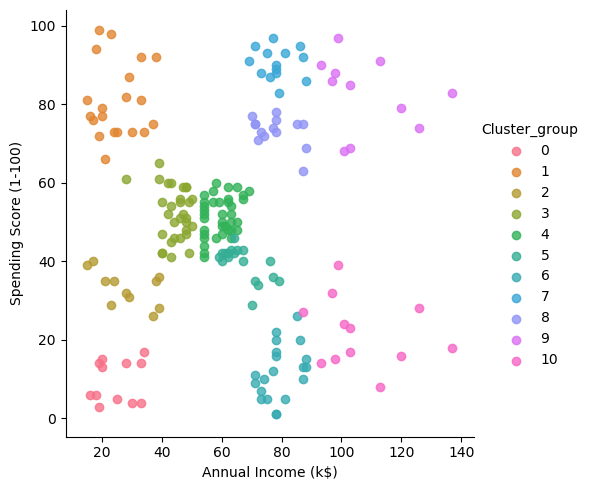

In [21]:
import seaborn as sns
facet=sns.lmplot(data=supervised, x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],
                fit_reg=False,legend=True,legend_out=True)